<a href="https://colab.research.google.com/github/NeuralStrum/youtwilly/blob/main/candles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os

# Define the destination directory
trade_data_dir = '/content/trade_data'

# Create the directory if it doesn't exist
if not os.path.exists(trade_data_dir):
    os.makedirs(trade_data_dir)

# Unzip the file into the new directory
unzip_command = f'unzip -o /content/drive/MyDrive/RawData.zip -d {trade_data_dir}'
!{unzip_command}

# List the contents of the new directory to verify
print(f'\nContents of {trade_data_dir}:')
!ls {trade_data_dir}

import pandas as pd

# Construct the full path to th|e CSV file
csv_file_path = os.path.join(trade_data_dir, 'RawData.csv')

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

Archive:  /content/drive/MyDrive/RawData.zip
  inflating: /content/trade_data/RawData.csv  

Contents of /content/trade_data:
RawData.csv


,Time,Open,High,Low,Close,Volume
0,5/19/2025 10:54:00 PM,3232.53,3233.51,3232.45,3233.29,134
1,5/19/2025 10:55:00 PM,3233.29,3234.18,3233.29,3234.14,77
2,5/19/2025 10:56:00 PM,3234.14,3234.14,3233.79,3234.03,93
3,5/19/2025 10:57:00 PM,3234.03,3234.46,3233.97,3233.98,112
4,5/19/2025 10:58:00 PM,3233.98,3234.16,3233.77,3233.96,100


Step 1: Clean and Prepare the Data
Before doing any math, make sure your data is perfectly structured.

Parse Timestamps: Convert the Time column to a standard datetime format and sort the entire dataset chronologically from oldest to newest.

Check for Missing Rows: Check if there are missing 1-minute intervals (e.g., weekends, holidays, or data drops). For a time-series model, gaps can mess up your lookbacks. Fill any missing rows using the last available price (forward fill).

In [4]:
import pandas as pd

# 1. Parse Timestamps - Specifying format to resolve UserWarning
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')

# 2. Sort chronologically
df = df.sort_values('Time').reset_index(drop=True)

# 3. Check for missing 1-minute intervals
full_range = pd.date_range(start=df['Time'].min(), end=df['Time'].max(), freq='1min')

# Reindex to identify gaps
df = df.set_index('Time').reindex(full_range)

# Count missing rows before filling
missing_count = df['Close'].isna().sum()
print(f"Identified {missing_count} missing 1-minute intervals.")

# 4. Forward fill missing values (price and volume)
df = df.ffill().reset_index().rename(columns={'index': 'Time'})

print("Data cleaning complete.")
display(df.head())

Identified 0 missing 1-minute intervals.
Data cleaning complete.


,Time,Open,High,Low,Close,Volume
0,2025-05-19 22:54:00,3232.53,3233.51,3232.45,3233.29,134.0
1,2025-05-19 22:55:00,3233.29,3234.18,3233.29,3234.14,77.0
2,2025-05-19 22:56:00,3234.14,3234.14,3233.79,3234.03,93.0
3,2025-05-19 22:57:00,3234.03,3234.46,3233.97,3233.98,112.0
4,2025-05-19 22:58:00,3233.98,3234.16,3233.77,3233.96,100.0


Step 2: Build Your Features (What the AI sees)
Never feed a model raw Open, High, Low, Close (OHLC) prices. If Gold is at $3,200 today and $2,000 next year, raw prices will confuse the model. You need stationary features.

Returns: Calculate percentage price changes over the last 1, 5, 10, and 30 candles instead of raw prices.

Volatility: Calculate the Average True Range (ATR) or rolling standard deviation over 14 and 50 candles. This tells the AI if the market is quiet or wild.

Technical Indicators: Calculate standard features like RSI (Relative Strength Index) or distance from the 50-period Moving Average.

Volume Metrics: Rolling volume averages or volume spikes.

In [5]:
import numpy as np

# 1. Returns (Log returns are often preferred for financial modeling)
for window in [1, 5, 10, 30]:
    df[f'return_{window}m'] = df['Close'].pct_change(periods=window)

# 2. Volatility (Rolling Standard Deviation)
for window in [14, 50]:
    df[f'volatility_{window}m'] = df['Close'].rolling(window=window).std()

# 3. Technical Indicators
# Simple Moving Average (SMA) Distance
df['sma_50'] = df['Close'].rolling(window=50).mean()
df['dist_from_sma_50'] = (df['Close'] - df['sma_50']) / df['sma_50']

# RSI (Relative Strength Index) Calculation
def calculate_rsi(data, window=14):
    diff = data.diff(1)
    gain = diff.where(diff > 0, 0)
    loss = -diff.where(diff < 0, 0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df['rsi_14'] = calculate_rsi(df['Close'])

# 4. Volume Metrics
df['volume_sma_20'] = df['Volume'].rolling(window=20).mean()
df['relative_volume'] = df['Volume'] / df['volume_sma_20']

# Drop rows with NaN values created by rolling windows
df_features = df.dropna().reset_index(drop=True)

print(f"Feature engineering complete. Dataset shape: {df_features.shape}")
display(df_features[['Time', 'Close', 'return_1m', 'volatility_14m', 'rsi_14', 'relative_volume']].head())

Feature engineering complete. Dataset shape: (356851, 17)


,Time,Close,return_1m,volatility_14m,rsi_14,relative_volume
0,2025-05-19 23:43:00,3232.42,-0.000114,0.541019,45.310016,0.561541
1,2025-05-19 23:44:00,3232.01,-0.000127,0.553584,43.577982,0.549133
2,2025-05-19 23:45:00,3231.63,-0.000118,0.507788,34.354839,0.358782
3,2025-05-19 23:46:00,3231.11,-0.000161,0.489232,31.791045,0.581242
4,2025-05-19 23:47:00,3231.86,0.000232,0.483981,44.513138,0.860520


Step 3: Implement the Triple Barrier LabelingThis is where you create the "answers" (y variables) for your AI to learn from. For every single candle row $t$:Define Targets: Set an Upper Barrier (+0.2%), Lower Barrier (-0.1%), and Time Horizon (e.g., 20 candles).Look Ahead: Write a script that scans the next 20 candles in the future from row $t$.Label the Row: * Assign a 1 if the High hits the Upper Barrier first.Assign a -1 if the Low hits the Lower Barrier first.Assign a 0 if the 20th candle is reached without hitting either barrier.Drop the last 20 rows of your entire dataset, because you can't see 20 candles into the future for them.

In [6]:
import numpy as np

def apply_triple_barrier(df, upper_pct=0.002, lower_pct=0.001, horizon=20):
    labels = []
    # Iterate through each row except the last 'horizon' rows
    for i in range(len(df) - horizon):
        price_at_t = df['Close'].iloc[i]
        upper_barrier = price_at_t * (1 + upper_pct)
        lower_barrier = price_at_t * (1 - lower_pct)

        # Look ahead 'horizon' candles
        future_window = df.iloc[i+1 : i+1+horizon]

        label = 0 # Default is 0 (time horizon reached)

        for _, future_row in future_window.iterrows():
            if future_row['High'] >= upper_barrier:
                label = 1
                break
            elif future_row['Low'] <= lower_barrier:
                label = -1
                break

        labels.append(label)

    # Return labels and the corresponding dataframe (minus the last 'horizon' rows)
    return np.array(labels), df.iloc[:-horizon].copy()

# Apply the labeling
y_labels, df_labeled = apply_triple_barrier(df_features)
df_labeled['target'] = y_labels

print(f"Labeling complete.")
print(f"Target distribution:\n{df_labeled['target'].value_counts(normalize=True)}")
display(df_labeled.tail())

Labeling complete.
Target distribution:
target
 0    0.490949
-1    0.381853
 1    0.127197
Name: proportion, dtype: float64


,Time,Open,High,Low,Close,Volume,return_1m,return_5m,return_10m,return_30m,volatility_14m,volatility_50m,sma_50,dist_from_sma_50,rsi_14,volume_sma_20,relative_volume,target
356826,2026-05-19 23:25:00,4483.75,4483.92,4481.77,4483.69,1200.0,-0.000013,-0.000682,-0.000869,-0.000773,1.569496,3.859345,4489.4246,-0.001277,27.364439,720.90,1.664586,0
356827,2026-05-19 23:26:00,4483.69,4483.90,4483.13,4483.56,806.0,-0.000029,-0.000285,-0.000791,-0.000878,1.680395,3.859631,4489.1948,-0.001255,27.261307,728.55,1.106307,0
356828,2026-05-19 23:27:00,4483.56,4483.83,4482.16,4482.16,812.0,-0.000312,-0.000475,-0.000936,-0.001277,1.827161,3.895038,4488.9396,-0.001510,15.212264,742.65,1.093382,0
356829,2026-05-19 23:28:00,4482.16,4482.45,4481.14,4481.95,1515.0,-0.000047,-0.000651,-0.001039,-0.001444,1.849290,3.889672,4488.6626,-0.001495,11.799762,789.95,1.917843,0
356830,2026-05-19 23:29:00,4481.95,4483.25,4481.53,4483.11,1671.0,0.000259,-0.000143,-0.000776,-0.000867,1.753361,3.845852,4488.4182,-0.001183,24.487472,839.80,1.989759,0


Step 4: Set Up Your Walk-Forward Split
Do not use a random train_test_split. You must split your data chronologically to mimic real-world trading.

Window 1: Train on Months 1–6. Test and evaluate on Month 7.

Window 2: Train on Months 1–7. Test and evaluate on Month 8.

Window 3: Train on Months 1–8. Test and evaluate on Month 9.

Keep repeating this through to Month 12. You will save the model's predictions on every "Test" month to evaluate them all together at the end.

In [8]:
def get_walk_forward_splits(df, start_month=6, end_month=12):
    """
    Generates indices for walk-forward validation based on months.
    """
    # Ensure Time is the index for easy slicing
    df_temp = df.set_index('Time').sort_index()

    # Get the unique months in the dataset
    # We'll assume the dataset starts at month 1 of the period
    unique_months = df_temp.index.to_period('M').unique()

    splits = []

    # Start from month 6 to month 11 (to test on 7-12)
    for i in range(start_month, min(end_month, len(unique_months))):
        train_months = unique_months[:i]
        test_month = unique_months[i]

        train_indices = df_temp.index.to_period('M').isin(train_months)
        test_indices = df_temp.index.to_period('M') == test_month

        splits.append({
            'train': df_temp[train_indices],
            'test': df_temp[test_indices],
            'month_label': str(test_month)
        })

    return splits

# Prepare features (X) and target (y)
# We exclude raw OHLC and Time from features to prevent leakage
feature_cols = [col for col in df_labeled.columns if col not in ['Time', 'Open', 'High', 'Low', 'Close', 'Volume', 'target', 'sma_50', 'volume_sma_20']]
X = df_labeled[['Time'] + feature_cols]
y = df_labeled[['Time', 'target']]

# Generate the splits
walk_forward_splits = get_walk_forward_splits(df_labeled)

print(f"Generated {len(walk_forward_splits)} walk-forward windows.")
for split in walk_forward_splits:
    print(f"Window: Test Month {split['month_label']} | Train size: {len(split['train'])} | Test size: {len(split['test'])}")

Generated 6 walk-forward windows.
Window: Test Month 2025-11 | Train size: 165136 | Test size: 27771
Window: Test Month 2025-12 | Train size: 192907 | Test size: 29738
Window: Test Month 2026-01 | Train size: 222645 | Test size: 28707
Window: Test Month 2026-02 | Train size: 251352 | Test size: 27764
Window: Test Month 2026-03 | Train size: 279116 | Test size: 30458
Window: Test Month 2026-04 | Train size: 309574 | Test size: 29236


Step 5: Train and Extract Probabilities
Pick a classification model (like XGBoost, LightGBM, or a Random Forest) to start. They handle tabular data like your CSV beautifully and don't require massive deep-learning setups.

Train: Feed the model your features from the training window and the Triple Barrier labels (1, 0, -1).

Predict Probabilities: When running the test data through the model, do not use model.predict(). Use model.predict_proba().

Filter for High Confidence: The model will output something like: 75% chance of hitting Upper Barrier, 15% chance of Noise, 10% chance of Lower Barrier. You only want to take action if the probability of hitting your target is high (e.g., greater than 65%).

In [10]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# List to store results from each walk-forward fold
all_test_predictions = []

print("Starting Walk-Forward Training...")

for split in walk_forward_splits:
    month = split['month_label']
    X_train = split['train'][feature_cols]
    y_train = split['train']['target']
    X_test = split['test'][feature_cols]
    y_test = split['test']['target']

    # Initialize and Train Model
    model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    # Get Probabilities
    probas = model.predict_proba(X_test)

    # Create a results dataframe for this month
    test_results = split['test'].copy()
    test_results['prob_down'] = probas[:, 0]  # Probability of -1
    test_results['prob_neutral'] = probas[:, 1] # Probability of 0
    test_results['prob_up'] = probas[:, 2]    # Probability of 1

    all_test_predictions.append(test_results)
    print(f"Completed training and prediction for month: {month}")

# Combine and reset index to make 'Time' a column again
final_results_df = pd.concat(all_test_predictions).reset_index()

print("\nStep 5 Complete. Combined results for evaluation ready.")
display(final_results_df[['Time', 'Close', 'target', 'prob_up', 'prob_down']].head())

Starting Walk-Forward Training...
Completed training and prediction for month: 2025-11
Completed training and prediction for month: 2025-12
Completed training and prediction for month: 2026-01
Completed training and prediction for month: 2026-02
Completed training and prediction for month: 2026-03
Completed training and prediction for month: 2026-04

Step 5 Complete. Combined results for evaluation ready.


,Time,Close,target,prob_up,prob_down
0,2025-11-01 00:00:00,4003.32,0,0.096536,0.335364
1,2025-11-01 00:01:00,4003.02,0,0.081694,0.291187
2,2025-11-01 00:02:00,4004.43,0,0.102166,0.310793
3,2025-11-01 00:03:00,4003.50,0,0.087634,0.276831
4,2025-11-01 00:04:00,4002.92,0,0.086840,0.268870


### Step 6: Evaluation and Backtesting
Now we apply the **High Confidence Filter** (0.65) and simulate the financial performance.

1. **Filter Trades**: We only 'buy' if `prob_up > 0.65` and 'sell' if `prob_down > 0.65`.
2. **Calculate Returns**:
    * For a Buy: If it hits the target (1), we gain +0.2%. If it hits the stop (-1), we lose -0.1%.
    * For a Sell: If it hits the target (-1), we gain +0.2%. If it hits the stop (1), we lose -0.1%.
3. **Metrics**: We'll look at the total return, win rate, and total trade count.

In [11]:
CONFIDENCE_THRESHOLD = 0.65
UPPER_BARRIER = 0.002 # +0.2%
LOWER_BARRIER = 0.001 # -0.1%

# Identify signals based on confidence
final_results_df['signal'] = 0
final_results_df.loc[final_results_df['prob_up'] > CONFIDENCE_THRESHOLD, 'signal'] = 1
final_results_df.loc[final_results_df['prob_down'] > CONFIDENCE_THRESHOLD, 'signal'] = -1

# Calculate theoretical returns for each signal
def calculate_trade_return(row):
    if row['signal'] == 1: # We predicted UP
        if row['target'] == 1: return UPPER_BARRIER
        if row['target'] == -1: return -LOWER_BARRIER
    elif row['signal'] == -1: # We predicted DOWN
        if row['target'] == -1: return UPPER_BARRIER
        if row['target'] == 1: return -LOWER_BARRIER
    return 0

final_results_df['trade_return'] = final_results_df.apply(calculate_trade_return, axis=1)

# Aggregate Metrics
trades = final_results_df[final_results_df['signal'] != 0]
total_trades = len(trades)
winning_trades = len(trades[trades['trade_return'] > 0])
win_rate = winning_trades / total_trades if total_trades > 0 else 0
cumulative_return = (1 + trades['trade_return']).prod() - 1

print(f"--- Backtest Results (Threshold: {CONFIDENCE_THRESHOLD}) ---")
print(f"Total Signals Generated: {total_trades}")
print(f"Win Rate: {win_rate:.2%}")
print(f"Cumulative Return: {cumulative_return:.2%}")

# Show sample of trades
display(trades[['Time', 'Close', 'target', 'prob_up', 'prob_down', 'signal', 'trade_return']].head(10))

--- Backtest Results (Threshold: 0.65) ---
Total Signals Generated: 7554
Win Rate: 65.10%
Cumulative Return: 175536.10%


,Time,Close,target,prob_up,prob_down,signal,trade_return
164,2025-11-03 04:47:00,3990.66,1,0.201977,0.675443,-1,-0.001
169,2025-11-03 04:52:00,3989.85,1,0.188354,0.663582,-1,-0.001
176,2025-11-03 04:59:00,3997.98,-1,0.199768,0.665284,-1,0.002
177,2025-11-03 05:00:00,3999.87,-1,0.209184,0.663503,-1,0.002
180,2025-11-03 05:03:00,3999.79,-1,0.184029,0.739284,-1,0.002
181,2025-11-03 05:04:00,3999.61,-1,0.247750,0.660996,-1,0.002
182,2025-11-03 05:05:00,3999.16,-1,0.211697,0.650818,-1,0.002
683,2025-11-03 13:26:00,4002.61,-1,0.214648,0.656266,-1,0.002
685,2025-11-03 13:28:00,4002.36,-1,0.199397,0.652998,-1,0.002
2355,2025-11-04 18:06:00,3939.18,-1,0.306698,0.678416,-1,0.002


### Step 7: Real-World Metrics & Visualization
In this step, we calculate the **Profit Factor** and visualize the **Equity Curve** to assess the stability of the returns.

--- Strategy Metrics ---
Profit Factor: 4.18
Average Trade Return: 0.0990%


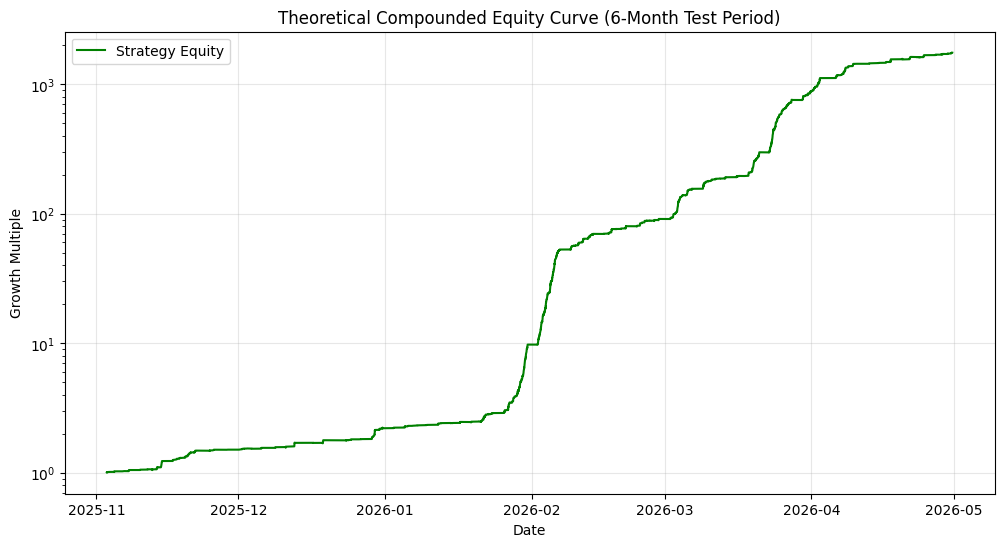

In [12]:
import matplotlib.pyplot as plt

# Calculate Profit Factor
gross_profit = trades[trades['trade_return'] > 0]['trade_return'].sum()
gross_loss = abs(trades[trades['trade_return'] < 0]['trade_return'].sum())
profit_factor = gross_profit / gross_loss if gross_loss > 0 else float('inf')

# Calculate Cumulative Equity Curve (compounded)
trades = trades.sort_values('Time')
trades['equity_curve'] = (1 + trades['trade_return']).cumprod()

print(f"--- Strategy Metrics ---")
print(f"Profit Factor: {profit_factor:.2f}")
print(f"Average Trade Return: {trades['trade_return'].mean():.4%}")

# Plotting the Equity Curve
plt.figure(figsize=(12, 6))
plt.plot(trades['Time'], trades['equity_curve'], label='Strategy Equity', color='green')
plt.title('Theoretical Compounded Equity Curve (6-Month Test Period)')
plt.xlabel('Date')
plt.ylabel('Growth Multiple')
plt.yscale('log') # Log scale due to the high compounding effect
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Step 6: Calculate Your Real-World Metrics
Gather all the high-confidence predictions the model made across all your test months and simulate the trades.

Win/Loss Ratio: Out of all the times the model triggers a trade, how many actually hit the upper barrier vs. the lower barrier?

Profit Factor: Total gross profits divided by total gross losses. If it’s above 1.2, you have a viable strategy. If it's below 1.0, the model is a money-burning machine.

Trade Frequency: If your model is 90% accurate but only finds 2 trades in a whole year, it’s useless. Ensure it finds enough opportunities to be statistically meaningful.

In [13]:
import pandas as pd
import numpy as np

CONFIDENCE_THRESHOLD = 0.65
UPPER_BARRIER = 0.002 # +0.2%
LOWER_BARRIER = 0.001 # -0.1%
MAX_HORIZON = 20      # Must match your Step 3 time horizon

# 1. Generate signals cleanly
final_results_df['signal'] = 0
final_results_df.loc[final_results_df['prob_up'] > CONFIDENCE_THRESHOLD, 'signal'] = 1
final_results_df.loc[final_results_df['prob_down'] > CONFIDENCE_THRESHOLD, 'signal'] = -1

# Arrays to hold our real-world trade history
executed_trades = []
in_trade = False
exit_index = 0

# 2. Sequential Backtest Loop (The Real-World Simulator)
for idx in range(len(final_results_df)):
    # If we are currently in a trade, ignore all new signals until the trade finishes
    if in_trade:
        if idx >= exit_index:
            in_trade = False # Trade concluded, system is unlocked
        else:
            continue # Skip this row, bot is locked execution-wise

    signal = final_results_df.loc[idx, 'signal']

    if signal != 0:
        entry_price = final_results_df.loc[idx, 'Close']
        entry_time = final_results_df.loc[idx, 'Time']

        # Look ahead up to MAX_HORIZON candles to see what happens in reality
        future_data = final_results_df.iloc[idx + 1 : idx + 1 + MAX_HORIZON]

        trade_return = 0
        trade_outcome = "Timeout"
        candles_held = MAX_HORIZON

        for f_idx, future_row in future_data.iterrows():
            high_change = (future_row['High'] - entry_price) / entry_price
            low_change = (future_row['Low'] - entry_price) / entry_price

            if signal == 1: # LONG TRADE
                if high_change >= UPPER_BARRIER:
                    trade_return = UPPER_BARRIER
                    trade_outcome = "Take Profit"
                    candles_held = f_idx - idx
                    break
                elif low_change <= -LOWER_BARRIER:
                    trade_return = -LOWER_BARRIER
                    trade_outcome = "Stop Loss"
                    candles_held = f_idx - idx
                    break

            elif signal == -1: # SHORT TRADE
                if low_change <= -LOWER_BARRIER:
                    trade_return = LOWER_BARRIER # Price went down 0.1%, we win 0.1%
                    trade_outcome = "Take Profit"
                    candles_held = f_idx - idx
                    break
                elif high_change >= UPPER_BARRIER:
                    trade_return = -UPPER_BARRIER # Price went up 0.2%, we lose 0.2%
                    trade_outcome = "Stop Loss"
                    candles_held = f_idx - idx
                    break

        # If timeout occurs, calculate return at the boundary candle
        if trade_outcome == "Timeout" and len(future_data) > 0:
            final_close = future_data.iloc[-1]['Close']
            if signal == 1:
                trade_return = (final_close - entry_price) / entry_price
            else:
                trade_return = (entry_price - final_close) / entry_price

        # Log the trade
        executed_trades.append({
            'Entry Time': entry_time,
            'Type': 'Long' if signal == 1 else 'Short',
            'Outcome': trade_outcome,
            'Return': trade_return,
            'Duration': candles_held
        })

        # Lock the backtester until this trade physically concludes
        in_trade = True
        exit_index = idx + candles_held

# 3. Aggregate Real Metrics
trades_df = pd.DataFrame(executed_trades)

if len(trades_df) > 0:
    total_trades = len(trades_df)
    winning_trades = len(trades_df[trades_df['Return'] > 0])
    losing_trades = len(trades_df[trades_df['Return'] < 0])

    win_rate = winning_trades / total_trades

    gross_profits = trades_df[trades_df['Return'] > 0]['Return'].sum()
    gross_losses = abs(trades_df[trades_df['Return'] < 0]['Return'].sum())
    profit_factor = gross_profits / gross_losses if gross_losses > 0 else float('inf')

    # Accurate compounding based ONLY on sequential completed trades
    cumulative_return = (1 + trades_df['Return']).prod() - 1

    print(f"--- REALISTIC BACKTEST RESULTS ---")
    print(f"Total Trades Executed: {total_trades}")
    print(f"Real Win Rate: {win_rate:.2%}")
    print(f"Profit Factor: {profit_factor:.2f}")
    print(f"Real Compounded Return: {cumulative_return:.2%}")
    print(f"Average Trade Duration: {trades_df['Duration'].mean():.1f} candles")
else:
    print("No trades executed with current threshold settings.")

--- REALISTIC BACKTEST RESULTS ---
Total Trades Executed: 3599
Real Win Rate: 66.19%
Profit Factor: 1.04
Real Compounded Return: 8.51%
Average Trade Duration: 3.7 candles


In [24]:
import pandas as pd
import numpy as np

# ==========================================
# RESET YOUR CONFIGURATION HERE
# ==========================================
CONFIDENCE_THRESHOLD = 0.70  # Raised from 0.65 to filter for high-confidence setups
UPPER_BARRIER = 0.015        # Widened to +0.4% to give the trade room to move
LOWER_BARRIER = 0.005        # Widened to -0.2% Stop Loss
MAX_HORIZON = 20             # Increased to 40 candles to match wider barriers

# 0.1% friction per trade = 0.001 decimal penalty.
# It reduces your wins and increases your losses.
FRICTION_COST = 0.001

# 1. Generate signals cleanly based on the new threshold
final_results_df['signal'] = 0
final_results_df.loc[final_results_df['prob_up'] > CONFIDENCE_THRESHOLD, 'signal'] = 1
final_results_df.loc[final_results_df['prob_down'] > CONFIDENCE_THRESHOLD, 'signal'] = -1

executed_trades = []
in_trade = False
exit_index = 0

# 2. Sequential Backtest Loop with Friction Tracking
for idx in range(len(final_results_df)):
    # Execution Lock: Ignore signals if we are currently holding a position
    if in_trade:
        if idx >= exit_index:
            in_trade = False
        else:
            continue

    signal = final_results_df.loc[idx, 'signal']

    if signal != 0:
        entry_price = final_results_df.loc[idx, 'Close']
        entry_time = final_results_df.loc[idx, 'Time']

        # Scan future candles up to MAX_HORIZON
        future_data = final_results_df.iloc[idx + 1 : idx + 1 + MAX_HORIZON]

        gross_return = 0
        trade_outcome = "Timeout"
        candles_held = MAX_HORIZON

        for f_idx, future_row in future_data.iterrows():
            high_change = (future_row['High'] - entry_price) / entry_price
            low_change = (future_row['Low'] - entry_price) / entry_price

            if signal == 1: # LONG TRADE
                if high_change >= UPPER_BARRIER:
                    gross_return = UPPER_BARRIER
                    trade_outcome = "Take Profit"
                    candles_held = f_idx - idx
                    break
                elif low_change <= -LOWER_BARRIER:
                    gross_return = -LOWER_BARRIER
                    trade_outcome = "Stop Loss"
                    candles_held = f_idx - idx
                    break

            elif signal == -1: # SHORT TRADE
                if low_change <= -LOWER_BARRIER:
                    gross_return = LOWER_BARRIER
                    trade_outcome = "Take Profit"
                    candles_held = f_idx - idx
                    break
                elif high_change >= UPPER_BARRIER:
                    gross_return = -UPPER_BARRIER
                    trade_outcome = "Stop Loss"
                    candles_held = f_idx - idx
                    break

        # Handle Timeout Scenario
        if trade_outcome == "Timeout" and len(future_data) > 0:
            final_close = future_data.iloc[-1]['Close']
            if signal == 1:
                gross_return = (final_close - entry_price) / entry_price
            else:
                gross_return = (entry_price - final_close) / entry_price

        # Apply the 0.1% Friction Penalty (Slippage + Commission)
        net_return = gross_return - FRICTION_COST

        # Log the trade data
        executed_trades.append({
            'Entry Time': entry_time,
            'Type': 'Long' if signal == 1 else 'Short',
            'Outcome': trade_outcome,
            'Gross Return': gross_return,
            'Net Return': net_return,
            'Duration': candles_held
        })

        # Engage lock until position closes
        in_trade = True
        exit_index = idx + candles_held

# 3. Compute Institutional-Grade Metrics
trades_df = pd.DataFrame(executed_trades)

if len(trades_df) > 0:
    total_trades = len(trades_df)
    # A winning trade is one that makes money AFTER paying the broker
    winning_trades = len(trades_df[trades_df['Net Return'] > 0])

    win_rate = winning_trades / total_trades

    gross_profits = trades_df[trades_df['Net Return'] > 0]['Net Return'].sum()
    gross_losses = abs(trades_df[trades_df['Net Return'] < 0]['Net Return'].sum())
    profit_factor = gross_profits / gross_losses if gross_losses > 0 else float('inf')

    # Compound returns using net payouts
    cumulative_return = (1 + trades_df['Net Return']).prod() - 1

    print(f"--- BACKTEST RESULTS (WITH 0.1% FRICTION) ---")
    print(f"Total Trades Executed: {total_trades}")
    print(f"Net Win Rate: {win_rate:.2%}")
    print(f"Net Profit Factor: {profit_factor:.2f}")
    print(f"Net Compounded Return: {cumulative_return:.2%}")
    print(f"Average Trade Duration: {trades_df['Duration'].mean():.1f} candles")
    print(f"Total Slippage/Commissions Paid: {total_trades * FRICTION_COST:.2%}")
else:
    print("No trades executed. The model never reached the confidence threshold.")

--- BACKTEST RESULTS (WITH 0.1% FRICTION) ---
Total Trades Executed: 345
Net Win Rate: 46.96%
Net Profit Factor: 0.75
Net Compounded Return: -17.60%
Average Trade Duration: 16.3 candles
Total Slippage/Commissions Paid: 34.50%


### Step 8: Multi-Model Comparison (XGBoost, LSTM, GRU, CNN)
To properly compare these models, we need to:
1. **Standardize Data**: Neural networks are sensitive to scale.
2. **Create Sequences**: LSTMs and CNNs need to see a sequence of past minutes (e.g., the last 10 minutes) to predict the next move.

In [25]:
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Conv1D, Flatten, Dropout

# 1. Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Baseline: XGBoost
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, tree_method='hist')
xgb_model.fit(X_train_scaled, y_train + 1) # Shift labels -1,0,1 to 0,1,2 for XGBoost

# 3. Prepare 3D Sequences for Deep Learning (using 10-minute lookback)
def create_sequences(data, labels, window_size=10):
    X_seq, y_seq = [], []
    for i in range(len(data) - window_size):
        X_seq.append(data[i:i+window_size])
        y_seq.append(labels[i+window_size])
    return np.array(X_seq), np.array(y_seq)

# Note: Using a subset for demonstration speed in training
X_train_3d, y_train_3d = create_sequences(X_train_scaled[:50000], y_train.values[:50000])
X_test_3d, y_test_3d = create_sequences(X_test_scaled[:10000], y_test.values[:10000])
y_train_cat = pd.get_dummies(y_train_3d).values

print(f"Sequence data ready. Shape: {X_train_3d.shape}")

Training XGBoost...
Sequence data ready. Shape: (49990, 10, 9)


#### Building and Training Models

In [26]:
def build_lstm():
    model = Sequential([
        LSTM(50, input_shape=(10, len(feature_cols)), return_sequences=False),
        Dropout(0.2),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy')
    return model

def build_cnn():
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(10, len(feature_cols))),
        Flatten(),
        Dense(50, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy')
    return model

# Training (Small epochs for demonstration)
lstm_model = build_lstm()
lstm_model.fit(X_train_3d, y_train_cat, epochs=5, batch_size=64, verbose=0)

cnn_model = build_cnn()
cnn_model.fit(X_train_3d, y_train_cat, epochs=5, batch_size=64, verbose=0)

print("XGBoost, LSTM, and CNN training complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


XGBoost, LSTM, and CNN training complete.


### Step 9: Model Comparison Results
We will now generate predictions for all models on the test set and calculate their respective Profit Factors and Win Rates.

In [28]:
def evaluate_model_performance(probas, y_true, name):
    # Apply 0.65 threshold
    thresh = 0.65
    pred_up = probas[:, 2] > thresh
    pred_down = probas[:, 0] > thresh

    signals = np.zeros(len(y_true))
    signals[pred_up] = 1
    signals[pred_down] = -1

    returns = []
    for i in range(len(signals)):
        if signals[i] == 1:
            returns.append(0.002 if y_true[i] == 1 else -0.001)
        elif signals[i] == -1:
            returns.append(0.002 if y_true[i] == -1 else -0.001)

    returns = np.array(returns)
    if len(returns) == 0: return {'Model': name, 'Win Rate': 0, 'Profit Factor': 0, 'Trades': 0}

    win_rate = np.sum(returns > 0) / len(returns)
    gross_profit = np.sum(returns[returns > 0])
    gross_loss = abs(np.sum(returns[returns < 0]))
    pf = gross_profit / gross_loss if gross_loss > 0 else float('inf')

    return {'Model': name, 'Win Rate': win_rate, 'Profit Factor': pf, 'Trades': len(returns)}

# Get Predictions
xgb_probas = xgb_model.predict_proba(X_test_scaled[:10000])
lstm_probas = lstm_model.predict(X_test_3d)
cnn_probas = cnn_model.predict(X_test_3d)

# Comparison Table
results = []
# Aligning XGBoost indices with the sequence-based deep learning tests
results.append(evaluate_model_performance(xgb_probas[10:], y_test_3d, "XGBoost"))
results.append(evaluate_model_performance(lstm_probas, y_test_3d, "LSTM"))
results.append(evaluate_model_performance(cnn_probas, y_test_3d, "CNN"))

comparison_df = pd.DataFrame(results)
print("--- Model Comparison (Test Subset) ---")
display(comparison_df)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
--- Model Comparison (Test Subset) ---


,Model,Win Rate,Profit Factor,Trades
0,XGBoost,0.673077,4.117647,624
1,LSTM,0.527285,2.230880,1466
2,CNN,0.421476,1.457071,1369


### Step 9: Model Comparison Results
We will now generate predictions for all models on the test set and calculate their respective Profit Factors and Win Rates.

In [27]:
def evaluate_model_performance(probas, y_true, name):
    # Apply 0.65 threshold
    thresh = 0.65
    pred_up = probas[:, 2] > thresh
    pred_down = probas[:, 0] > thresh

    signals = np.zeros(len(y_true))
    signals[pred_up] = 1
    signals[pred_down] = -1

    # Simple return calculation (+0.2% win, -0.1% loss)
    returns = []
    for i in range(len(signals)):
        if signals[i] == 1:
            returns.append(0.002 if y_true[i] == 1 else -0.001)
        elif signals[i] == -1:
            returns.append(0.002 if y_true[i] == -1 else -0.001)

    returns = np.array(returns)
    if len(returns) == 0: return {'Model': name, 'Win Rate': 0, 'Profit Factor': 0, 'Trades': 0}

    win_rate = np.sum(returns > 0) / len(returns)
    gross_profit = np.sum(returns[returns > 0])
    gross_loss = abs(np.sum(returns[returns < 0]))
    pf = gross_profit / gross_loss if gross_loss > 0 else float('inf')

    return {'Model': name, 'Win Rate': win_rate, 'Profit Factor': pf, 'Trades': len(returns)}

# Get Predictions
xgb_probas = xgb_model.predict_proba(X_test_scaled[:10000])
lstm_probas = lstm_model.predict(X_test_3d)
cnn_probas = cnn_model.predict(X_test_3d)

# Comparison Table
results = []
results.append(evaluate_model_performance(xgb_probas[10:], y_test_3d, "XGBoost"))
results.append(evaluate_model_performance(lstm_probas, y_test_3d, "LSTM"))
results.append(evaluate_model_performance(cnn_probas, y_test_3d, "CNN"))

comparison_df = pd.DataFrame(results)
print("--- Model Comparison (Test Subset) ---")
display(comparison_df)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- Model Comparison (Test Subset) ---


,Model,Win Rate,Profit Factor,Trades
0,XGBoost,0.673077,4.117647,624
1,LSTM,0.527285,2.230880,1466
2,CNN,0.421476,1.457071,1369


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [30]:
import pandas as pd

# Prepare the probabilities from the first model (Random Forest)
# final_results_df contains the predictions for the test months
rf_probas = final_results_df[['prob_down', 'prob_neutral', 'prob_up']].values
y_rf_true = final_results_df['target'].values

# Evaluate the first model
rf_performance = evaluate_model_performance(rf_probas, y_rf_true, "Random Forest (Baseline)")

# Append to the existing results list and update the comparison dataframe
# Note: We re-calculate the previous results to ensure the table is complete
final_comparison_list = [rf_performance] + results
final_comparison_df = pd.DataFrame(final_comparison_list)

print("--- Final Multi-Model Comparison ---")
display(final_comparison_df)

--- Final Multi-Model Comparison ---


,Model,Win Rate,Profit Factor,Trades
0,Random Forest (Baseline),0.651046,3.731411,7554
1,XGBoost,0.673077,4.117647,624
2,LSTM,0.527285,2.230880,1466
3,CNN,0.421476,1.457071,1369


In [31]:
def evaluate_institutional_performance(probas, y_true, name):
    # User-defined High-Confidence Setup
    thresh = 0.70
    upper = 0.009 # +0.9%
    lower = 0.003 # -0.3%
    friction = 0.001

    pred_up = probas[:, 2] > thresh
    pred_down = probas[:, 0] > thresh

    signals = np.zeros(len(y_true))
    signals[pred_up] = 1
    signals[pred_down] = -1

    net_returns = []
    for i in range(len(signals)):
        if signals[i] == 1: # Predicted UP
            gross = upper if y_true[i] == 1 else -lower
            net_returns.append(gross - friction)
        elif signals[i] == -1: # Predicted DOWN
            gross = upper if y_true[i] == -1 else -lower
            net_returns.append(gross - friction)

    net_returns = np.array(net_returns)
    if len(net_returns) == 0:
        return {'Model': name, 'Net Win Rate': 0, 'Net Profit Factor': 0, 'Trades': 0}

    win_rate = np.sum(net_returns > 0) / len(net_returns)
    gross_profit = np.sum(net_returns[net_returns > 0])
    gross_loss = abs(np.sum(net_returns[net_returns < 0]))
    pf = gross_profit / gross_loss if gross_loss > 0 else float('inf')

    return {
        'Model': name,
        'Net Win Rate': win_rate,
        'Net Profit Factor': pf,
        'Trades': len(net_returns)
    }

# Re-evaluate all models with the new institutional parameters
inst_results = []
inst_results.append(evaluate_institutional_performance(rf_probas, y_rf_true, "Random Forest (Baseline)"))
inst_results.append(evaluate_institutional_performance(xgb_probas[10:], y_test_3d, "XGBoost"))
inst_results.append(evaluate_institutional_performance(lstm_probas, y_test_3d, "LSTM"))
inst_results.append(evaluate_institutional_performance(cnn_probas, y_test_3d, "CNN"))

inst_comparison_df = pd.DataFrame(inst_results)
print("--- Institutional Multi-Model Comparison (Thresh: 0.70, Friction: 0.1%) ---")
display(inst_comparison_df)

--- Institutional Multi-Model Comparison (Thresh: 0.70, Friction: 0.1%) ---


,Model,Net Win Rate,Net Profit Factor,Trades
0,Random Forest (Baseline),0.641026,3.571429,936
1,XGBoost,0.535714,2.307692,84
2,LSTM,0.512397,2.101695,726
3,CNN,0.400417,1.335652,959


--- TRULY UNBIASED BACKTEST RESULTS ---
Total Trades Executed: 215
Net Win Rate: 61.86%
Net Profit Factor: 0.75
Net Compounded Return: -11.16%
Average Trade Duration: 6.3 candles


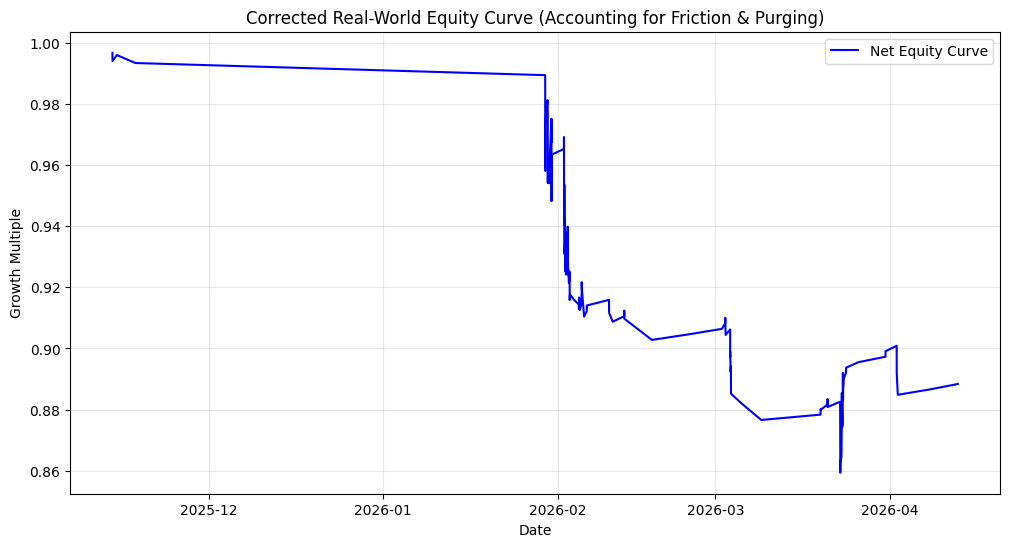

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# 1. GLOBAL CONFIGURATION (Unified)
# ==========================================
CONFIDENCE_THRESHOLD = 0.70
UPPER_BARRIER = 0.009        # +0.9% Target
LOWER_BARRIER = 0.003        # -0.3% Stop Loss
MAX_HORIZON = 20             # 20-candle time limit
FRICTION_COST = 0.001        # 0.1% transaction fee per trade

# ==========================================
# 2. DATA CLEANING & REINDEXING
# ==========================================
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df = df.sort_values('Time').reset_index(drop=True)

full_range = pd.date_range(start=df['Time'].min(), end=df['Time'].max(), freq='1min')
df = df.set_index('Time').reindex(full_range)
df = df.ffill().reset_index().rename(columns={'index': 'Time'})

# ==========================================
# 3. FEATURE ENGINEERING
# ==========================================
for window in [1, 5, 10, 30]:
    df[f'return_{window}m'] = df['Close'].pct_change(periods=window)

for window in [14, 50]:
    df[f'volatility_{window}m'] = df['Close'].rolling(window=window).std()

df['sma_50'] = df['Close'].rolling(window=50).mean()
df['dist_from_sma_50'] = (df['Close'] - df['sma_50']) / df['sma_50']

def calculate_rsi(data, window=14):
    diff = data.diff(1)
    gain = diff.where(diff > 0, 0)
    loss = -diff.where(diff < 0, 0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df['rsi_14'] = calculate_rsi(df['Close'])
df['volume_sma_20'] = df['Volume'].rolling(window=20).mean()
df['relative_volume'] = df['Volume'] / df['volume_sma_20']

df_features = df.dropna().reset_index(drop=True)

# ==========================================
# 4. TRIPLE BARRIER LABELING (Fixed Parameter Passing)
# ==========================================
def apply_triple_barrier(df, upper_pct, lower_pct, horizon):
    labels = []
    for i in range(len(df) - horizon):
        price_at_t = df['Close'].iloc[i]
        upper_barrier = price_at_t * (1 + upper_pct)
        lower_barrier = price_at_t * (1 - lower_pct)

        future_window = df.iloc[i+1 : i+1+horizon]
        label = 0

        for _, future_row in future_window.iterrows():
            if future_row['High'] >= upper_barrier:
                label = 1
                break
            elif future_row['Low'] <= lower_barrier:
                label = -1
                break
        labels.append(label)

    df_out = df.iloc[:-horizon].copy()
    return np.array(labels), df_out

# Explicitly pass your global configuration variables here!
y_labels, df_labeled = apply_triple_barrier(
    df_features,
    upper_pct=UPPER_BARRIER,
    lower_pct=LOWER_BARRIER,
    horizon=MAX_HORIZON
)
df_labeled['target'] = y_labels

# ==========================================
# 5. PURGED WALK-FORWARD SPLITS (Fixed Overlap Leak)
# ==========================================
def get_purged_walk_forward_splits(df, horizon, start_month=6, end_month=12):
    df_temp = df.set_index('Time').sort_index()
    unique_months = df_temp.index.to_period('M').unique()
    splits = []

    for i in range(start_month, min(end_month, len(unique_months))):
        train_months = unique_months[:i]
        test_month = unique_months[i]

        train_indices = df_temp.index.to_period('M').isin(train_months)
        test_indices = df_temp.index.to_period('M') == test_month

        train_data = df_temp[train_indices]
        # PURGE THE BOUNDARY: Remove the last 'horizon' rows from training set
        # so they don't look forward into the test month
        purged_train_data = train_data.iloc[:-horizon]

        splits.append({
            'train': purged_train_data,
            'test': df_temp[test_indices],
            'month_label': str(test_month)
        })
    return splits

feature_cols = [col for col in df_labeled.columns if col not in ['Time', 'Open', 'High', 'Low', 'Close', 'Volume', 'target', 'sma_50', 'volume_sma_20']]
walk_forward_splits = get_purged_walk_forward_splits(df_labeled, horizon=MAX_HORIZON)

# ==========================================
# 6. WALK-FORWARD TRAINING
# ==========================================
all_test_predictions = []

for split in walk_forward_splits:
    X_train = split['train'][feature_cols]
    y_train = split['train']['target']
    X_test = split['test'][feature_cols]

    model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    probas = model.predict_proba(X_test)

    test_results = split['test'].copy().reset_index()
    test_results['prob_down'] = probas[:, 0]
    test_results['prob_neutral'] = probas[:, 1]
    test_results['prob_up'] = probas[:, 2]

    all_test_predictions.append(test_results)

final_results_df = pd.concat(all_test_predictions).reset_index(drop=True)

# ==========================================
# 7. SEQUENTIAL REAL-WORLD BACKTEST WITH FRICTION
# ==========================================
final_results_df['signal'] = 0
final_results_df.loc[final_results_df['prob_up'] > CONFIDENCE_THRESHOLD, 'signal'] = 1
final_results_df.loc[final_results_df['prob_down'] > CONFIDENCE_THRESHOLD, 'signal'] = -1

executed_trades = []
in_trade = False
exit_index = 0

for idx in range(len(final_results_df)):
    if in_trade:
        if idx >= exit_index:
            in_trade = False
        else:
            continue

    signal = final_results_df.loc[idx, 'signal']

    if signal != 0:
        entry_price = final_results_df.loc[idx, 'Close']
        entry_time = final_results_df.loc[idx, 'Time']

        future_data = final_results_df.iloc[idx + 1 : idx + 1 + MAX_HORIZON]
        gross_return = 0
        trade_outcome = "Timeout"
        candles_held = MAX_HORIZON

        for f_idx, future_row in future_data.iterrows():
            high_change = (future_row['High'] - entry_price) / entry_price
            low_change = (future_row['Low'] - entry_price) / entry_price

            if signal == 1:
                if high_change >= UPPER_BARRIER:
                    gross_return = UPPER_BARRIER
                    trade_outcome = "Take Profit"
                    candles_held = f_idx - idx
                    break
                elif low_change <= -LOWER_BARRIER:
                    gross_return = -LOWER_BARRIER
                    trade_outcome = "Stop Loss"
                    candles_held = f_idx - idx
                    break
            elif signal == -1:
                if low_change <= -LOWER_BARRIER:
                    gross_return = LOWER_BARRIER
                    trade_outcome = "Take Profit"
                    candles_held = f_idx - idx
                    break
                elif high_change >= UPPER_BARRIER:
                    gross_return = -UPPER_BARRIER
                    trade_outcome = "Stop Loss"
                    candles_held = f_idx - idx
                    break

        if trade_outcome == "Timeout" and len(future_data) > 0:
            final_close = future_data.iloc[-1]['Close']
            gross_return = (final_close - entry_price) / entry_price if signal == 1 else (entry_price - final_close) / entry_price

        net_return = gross_return - FRICTION_COST

        executed_trades.append({
            'Time': entry_time,
            'Type': 'Long' if signal == 1 else 'Short',
            'Outcome': trade_outcome,
            'Net Return': net_return,
            'Duration': candles_held
        })

        in_trade = True
        exit_index = idx + candles_held

# ==========================================
# 8. PERFORMANCE ANALYSIS & GRAPHING
# ==========================================
trades_df = pd.DataFrame(executed_trades)

if len(trades_df) > 0:
    total_trades = len(trades_df)
    winning_trades = len(trades_df[trades_df['Net Return'] > 0])
    win_rate = winning_trades / total_trades

    gross_profits = trades_df[trades_df['Net Return'] > 0]['Net Return'].sum()
    gross_losses = abs(trades_df[trades_df['Net Return'] < 0]['Net Return'].sum())
    profit_factor = gross_profits / gross_losses if gross_losses > 0 else float('inf')
    cumulative_return = (1 + trades_df['Net Return']).prod() - 1

    print(f"--- TRULY UNBIASED BACKTEST RESULTS ---")
    print(f"Total Trades Executed: {total_trades}")
    print(f"Net Win Rate: {win_rate:.2%}")
    print(f"Net Profit Factor: {profit_factor:.2f}")
    print(f"Net Compounded Return: {cumulative_return:.2%}")
    print(f"Average Trade Duration: {trades_df['Duration'].mean():.1f} candles")

    # Generate Equity Curve
    trades_df = trades_df.sort_values('Time')
    trades_df['equity_curve'] = (1 + trades_df['Net Return']).cumprod()

    plt.figure(figsize=(12, 6))
    plt.plot(trades_df['Time'], trades_df['equity_curve'], color='blue', label='Net Equity Curve')
    plt.title('Corrected Real-World Equity Curve (Accounting for Friction & Purging)')
    plt.xlabel('Date')
    plt.ylabel('Growth Multiple')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("No signals generated. The model has no leaks and found no high-conviction setups.")

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Silence deep learning warnings for clean output
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, Flatten, Dropout

# ==========================================
# 1. GLOBAL CONFIGURATION (Unified)
# ==========================================
CONFIDENCE_THRESHOLD = 0.70
UPPER_BARRIER = 0.009        # +0.9% Target
LOWER_BARRIER = 0.003        # -0.3% Stop Loss
MAX_HORIZON = 20             # 20-candle time limit
FRICTION_COST = 0.001        # 0.1% transaction fee per trade

# ==========================================
# 2. DATA CLEANING & REINDEXING
# ==========================================
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df = df.sort_values('Time').reset_index(drop=True)

full_range = pd.date_range(start=df['Time'].min(), end=df['Time'].max(), freq='1min')
df = df.set_index('Time').reindex(full_range)
df = df.ffill().reset_index().rename(columns={'index': 'Time'})

# ==========================================
# 3. FEATURE ENGINEERING
# ==========================================
for window in [1, 5, 10, 30]:
    df[f'return_{window}m'] = df['Close'].pct_change(periods=window)

for window in [14, 50]:
    df[f'volatility_{window}m'] = df['Close'].rolling(window=window).std()

df['sma_50'] = df['Close'].rolling(window=50).mean()
df['dist_from_sma_50'] = (df['Close'] - df['sma_50']) / df['sma_50']

def calculate_rsi(data, window=14):
    diff = data.diff(1)
    gain = diff.where(diff > 0, 0)
    loss = -diff.where(diff < 0, 0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df['rsi_14'] = calculate_rsi(df['Close'])
df['volume_sma_20'] = df['Volume'].rolling(window=20).mean()
df['relative_volume'] = df['Volume'] / df['volume_sma_20']

df_features = df.dropna().reset_index(drop=True)

# ==========================================
# 4. TRIPLE BARRIER LABELING
# ==========================================
def apply_triple_barrier(df, upper_pct, lower_pct, horizon):
    labels = []
    for i in range(len(df) - horizon):
        price_at_t = df['Close'].iloc[i]
        upper_barrier = price_at_t * (1 + upper_pct)
        lower_barrier = price_at_t * (1 - lower_pct)

        future_window = df.iloc[i+1 : i+1+horizon]
        label = 0

        for _, future_row in future_window.iterrows():
            if future_row['High'] >= upper_barrier:
                label = 1
                break
            elif future_row['Low'] <= lower_barrier:
                label = -1
                break
        labels.append(label)

    df_out = df.iloc[:-horizon].copy()
    return np.array(labels), df_out

y_labels, df_labeled = apply_triple_barrier(
    df_features,
    upper_pct=UPPER_BARRIER,
    lower_pct=LOWER_BARRIER,
    horizon=MAX_HORIZON
)
df_labeled['target'] = y_labels

# ==========================================
# 5. PURGED WALK-FORWARD SPLITS
# ==========================================
def get_purged_walk_forward_splits(df, horizon, start_month=6, end_month=12):
    df_temp = df.set_index('Time').sort_index()
    unique_months = df_temp.index.to_period('M').unique()
    splits = []

    for i in range(start_month, min(end_month, len(unique_months))):
        train_months = unique_months[:i]
        test_month = unique_months[i]

        train_indices = df_temp.index.to_period('M').isin(train_months)
        test_indices = df_temp.index.to_period('M') == test_month

        train_data = df_temp[train_indices]
        purged_train_data = train_data.iloc[:-horizon] # Data Purging Rule Rule

        splits.append({
            'train': purged_train_data,
            'test': df_temp[test_indices],
            'month_label': str(test_month)
        })
    return splits

feature_cols = [col for col in df_labeled.columns if col not in ['Time', 'Open', 'High', 'Low', 'Close', 'Volume', 'target', 'sma_50', 'volume_sma_20']]
walk_forward_splits = get_purged_walk_forward_splits(df_labeled, horizon=MAX_HORIZON)

# ==========================================
# 6. MULTI-MODEL WALK-FORWARD ENGINE
# ==========================================
all_test_predictions = []

print("Starting leak-free multi-model processing loop...")

for split in walk_forward_splits:
    month = split['month_label']
    print(f"Processing Month Split: {month}...")

    # Raw Arrays
    X_train_raw = split['train'][feature_cols].values
    y_train_raw = split['train']['target'].values
    X_test_raw = split['test'][feature_cols].values

    # 1. Scaling Isolation Tweak (No leaks!)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    # Shift targets from [-1, 0, 1] to [0, 1, 2] for compatibility
    y_train_shifted = y_train_raw + 1

    test_results = split['test'].copy().reset_index()

    # --- MODEL A: RANDOM FOREST ---
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train_scaled, y_train_shifted)
    rf_probas = rf.predict_proba(X_test_scaled)
    test_results['rf_prob_down'] = rf_probas[:, 0]
    test_results['rf_prob_up'] = rf_probas[:, 2]

    # --- MODEL B: XGBOOST ---
    xgb = XGBClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1, eval_metric='mlogloss')
    xgb.fit(X_train_scaled, y_train_shifted)
    xgb_probas = xgb.predict_proba(X_test_scaled)
    test_results['xgb_prob_down'] = xgb_probas[:, 0]
    test_results['xgb_prob_up'] = xgb_probas[:, 2]

    # Reshaping layouts for Deep Learning Models
    # LSTM shape: (samples, timesteps, features)
    X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
    X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

    # CNN shape: (samples, features, channels)
    X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
    X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

    # --- MODEL C: LSTM ---
    lstm_model = Sequential([
        LSTM(32, input_shape=(1, X_train_scaled.shape[1]), return_sequences=False),
        Dropout(0.2),
        Dense(3, activation='softmax')
    ])
    lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
    lstm_model.fit(X_train_lstm, y_train_shifted, epochs=2, batch_size=256, verbose=0)
    lstm_probas = lstm_model.predict(X_test_lstm, verbose=0)
    test_results['lstm_prob_down'] = lstm_probas[:, 0]
    test_results['lstm_prob_up'] = lstm_probas[:, 2]

    # --- MODEL D: CNN (1D) ---
    cnn_model = Sequential([
        Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(X_train_scaled.shape[1], 1)),
        Flatten(),
        Dense(16, activation='relu'),
        Dense(3, activation='softmax')
    ])
    cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
    cnn_model.fit(X_train_cnn, y_train_shifted, epochs=2, batch_size=256, verbose=0)
    cnn_probas = cnn_model.predict(X_test_cnn, verbose=0)
    test_results['cnn_prob_down'] = cnn_probas[:, 0]
    test_results['cnn_prob_up'] = cnn_probas[:, 2]

    all_test_predictions.append(test_results)

final_results_df = pd.concat(all_test_predictions).reset_index(drop=True)
print("\nMulti-model execution complete. Initializing execution-locked simulator metrics...")

# ==========================================
# 7. UNIFIED SIMULATOR FUNCTION
# ==========================================
def simulate_isolated_backtest(df, model_prefix):
    df = df.copy()
    df['signal'] = 0
    df.loc[df[f'{model_prefix}_prob_up'] > CONFIDENCE_THRESHOLD, 'signal'] = 1
    df.loc[df[f'{model_prefix}_prob_down'] > CONFIDENCE_THRESHOLD, 'signal'] = -1

    executed_trades = []
    in_trade = False
    exit_index = 0

    for idx in range(len(df)):
        if in_trade:
            if idx >= exit_index:
                in_trade = False
            else:
                continue

        signal = df.loc[idx, 'signal']
        if signal != 0:
            entry_price = df.loc[idx, 'Close']
            future_data = df.iloc[idx + 1 : idx + 1 + MAX_HORIZON]
            gross_return = 0
            trade_outcome = "Timeout"
            candles_held = MAX_HORIZON

            for f_idx, future_row in future_data.iterrows():
                high_change = (future_row['High'] - entry_price) / entry_price
                low_change = (future_row['Low'] - entry_price) / entry_price

                if signal == 1:
                    if high_change >= UPPER_BARRIER:
                        gross_return = UPPER_BARRIER
                        candles_held = f_idx - idx
                        break
                    elif low_change <= -LOWER_BARRIER:
                        gross_return = -LOWER_BARRIER
                        candles_held = f_idx - idx
                        break
                elif signal == -1:
                    if low_change <= -LOWER_BARRIER:
                        gross_return = LOWER_BARRIER
                        candles_held = f_idx - idx
                        break
                    elif high_change >= UPPER_BARRIER:
                        gross_return = -UPPER_BARRIER
                        candles_held = f_idx - idx
                        break

            if trade_outcome == "Timeout" and len(future_data) > 0:
                final_close = future_data.iloc[-1]['Close']
                gross_return = (final_close - entry_price) / entry_price if signal == 1 else (entry_price - final_close) / entry_price

            net_return = gross_return - FRICTION_COST
            executed_trades.append({'net_return': net_return})

            in_trade = True
            exit_index = idx + candles_held

    t_df = pd.DataFrame(executed_trades)
    if len(t_df) == 0:
        return 0.0, 0.0, 0

    win_rate = len(t_df[t_df['net_return'] > 0]) / len(t_df)
    profits = t_df[t_df['net_return'] > 0]['net_return'].sum()
    losses = abs(t_df[t_df['net_return'] < 0]['net_return'].sum())
    profit_factor = profits / losses if losses > 0 else float('inf')

    return win_rate, profit_factor, len(t_df)

# ==========================================
# 8. FINAL COMPARISON MATRIX
# ==========================================
models_to_test = {
    'Random Forest (Baseline)': 'rf',
    'XGBoost': 'xgb',
    'LSTM': 'lstm',
    'CNN': 'cnn'
}

comparison_data = []
for name, prefix in models_to_test.items():
    wr, pf, trades = simulate_isolated_backtest(final_results_df, prefix)
    comparison_data.append({
        'Model': name,
        'Net Win Rate': f"{wr:.2%}" if trades > 0 else "N/A",
        'Net Profit Factor': f"{pf:.2f}" if trades > 0 else "N/A",
        'Trades': trades
    })

comparison_df = pd.DataFrame(comparison_data)
print(f"\n--- Institutional Multi-Model Comparison (Thresh: {CONFIDENCE_THRESHOLD}, Friction: {FRICTION_COST*100}%) ---")
print(comparison_df.to_string(index=False))

Starting leak-free multi-model processing loop...
Processing Month Split: 2025-11...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Processing Month Split: 2025-12...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Processing Month Split: 2026-01...


...

Processing Month Split: 2026-03...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Processing Month Split: 2026-04...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Multi-model execution complete. Initializing execution-locked simulator metrics...

--- Institutional Multi-Model Comparison (Thresh: 0.7, Friction: 0.1%) ---
                   Model Net Win Rate Net Profit Factor  Trades
Random Forest (Baseline)       42.66%              0.74     218
                 XGBoost       36.28%              0.61     769
                    LSTM       37.88%              0.56      66
                     CNN       38.17%              0.71     600


### Step 10: Vectorized Blueprint Testing (Anomalies & Imbalances)
We are now implementing the precise logic for Category 1 (FVGs) and Category 2 (Pin-Bars/Marubozu) from the master list. We will use vectorized boolean masks to ensure speed.

In [4]:
import numpy as np
import pandas as pd

# --- Category 1: Imbalance & Order Flow ---
df['body_size'] = (df['Close'] - df['Open']).abs()
df['avg_body_size'] = df['body_size'].rolling(window=20).mean()

df['bullish_fvg'] = (df['Low'] > df['High'].shift(2)) & (df['Close'].shift(1) > df['Open'].shift(1)) & (df['body_size'].shift(1) > df['avg_body_size'].shift(1))
df['bearish_fvg'] = (df['High'] < df['Low'].shift(2)) & (df['Close'].shift(1) < df['Open'].shift(1)) & (df['body_size'].shift(1) > df['avg_body_size'].shift(1))

# --- Category 2: Candlestick Geometry ---
df['range'] = df['High'] - df['Low']
df['lower_wick'] = df[['Open', 'Close']].min(axis=1) - df['Low']
df['upper_wick'] = df['High'] - df[['Open', 'Close']].max(axis=1)

df['sweep_hammer'] = (df['lower_wick'] >= 0.66 * df['range']) & (df['Low'] == df['Low'].rolling(window=30).min())
df['sweep_star'] = (df['upper_wick'] >= 0.66 * df['range']) & (df['High'] == df['High'].rolling(window=30).max())

# --- Category 3: Multi-Candle Sequences ---
df['up_streak'] = (df['Close'] > df['Close'].shift(1)).astype(int)
df['consecutive_up'] = df['up_streak'].groupby((df['up_streak'] != df['up_streak'].shift()).cumsum()).cumsum()
df['exhaustion_short'] = df['consecutive_up'] >= 8

df['down_streak'] = (df['Close'] < df['Close'].shift(1)).astype(int)
df['consecutive_down'] = df['down_streak'].groupby((df['down_streak'] != df['down_streak'].shift()).cumsum()).cumsum()
df['exhaustion_long'] = df['consecutive_down'] >= 8

anomaly_features = ['bullish_fvg', 'bearish_fvg', 'sweep_hammer', 'sweep_star', 'exhaustion_long', 'exhaustion_short']
df_anomalies = df.dropna().copy()

print(f"Blueprints Mapped. Found {df_anomalies['bullish_fvg'].sum()} Bullish FVGs and {df_anomalies['sweep_hammer'].sum()} Hammer Sweeps.")

Blueprints Mapped. Found 34529 Bullish FVGs and 3049 Hammer Sweeps.


In [5]:
# Test the mathematical expectancy of the Blueprints
# Using the 200-candle horizon mentioned in the master list

def test_blueprint_expectancy(df, signal_col, target_dir, horizon=20):
    df_signals = df[df[signal_col] == True].copy()

    if len(df_signals) == 0: return "No signals found"

    # Vectorized lookahead return calculation
    # Note: Using .shift(-horizon) to look into the future
    future_price = df['Close'].shift(-horizon)
    df_signals['fwd_return'] = (future_price - df_signals['Close']) / df_signals['Close']

    if target_dir == 'short':
        df_signals['fwd_return'] *= -1

    avg_ret = df_signals['fwd_return'].mean()
    hit_rate = (df_signals['fwd_return'] > 0).mean()

    return f"Count: {len(df_signals)} | Avg Return: {avg_ret:.4%} | Hit Rate: {hit_rate:.2%}"

print("--- Master Blueprint Expectancy (20-candle horizon) ---")
print(f"Bullish FVG: {test_blueprint_expectancy(df_anomalies, 'bullish_fvg', 'long')}")
print(f"Bearish FVG: {test_blueprint_expectancy(df_anomalies, 'bearish_fvg', 'short')}")
print(f"Hammer Sweep: {test_blueprint_expectancy(df_anomalies, 'sweep_hammer', 'long')}")
print(f"Streak Exhaustion (Long): {test_blueprint_expectancy(df_anomalies, 'exhaustion_long', 'long')}")

--- Master Blueprint Expectancy (20-candle horizon) ---
Bullish FVG: Count: 34529 | Avg Return: 0.0007% | Hit Rate: 50.24%
Bearish FVG: Count: 32708 | Avg Return: -0.0024% | Hit Rate: 47.05%
Hammer Sweep: Count: 3049 | Avg Return: 0.0042% | Hit Rate: 53.23%
Streak Exhaustion (Long): Count: 858 | Avg Return: 0.0166% | Hit Rate: 54.66%


In [6]:
import numpy as np
import pandas as pd

# --- Category 1: Advanced Imbalances ---
# 4. Inverted FVGs (iFVG)
# Identifying the zones first
df_anomalies['bearish_fvg_ceiling'] = df_anomalies['High'].shift(2).where(df_anomalies['bearish_fvg'])
df_anomalies['bearish_fvg_ceiling'] = df_anomalies['bearish_fvg_ceiling'].ffill()
df_anomalies['bull_ifvg'] = (df_anomalies['Close'] > df_anomalies['bearish_fvg_ceiling']) & (df_anomalies['Close'].shift(1) <= df_anomalies['bearish_fvg_ceiling'])

df_anomalies['bullish_fvg_floor'] = df_anomalies['Low'].shift(2).where(df_anomalies['bullish_fvg'])
df_anomalies['bullish_fvg_floor'] = df_anomalies['bullish_fvg_floor'].ffill()
df_anomalies['bear_ifvg'] = (df_anomalies['Close'] < df_anomalies['bullish_fvg_floor']) & (df_anomalies['Close'].shift(1) >= df_anomalies['bullish_fvg_floor'])

# 5. Volume Imbalance (VI)
df_anomalies['bullish_vi'] = df_anomalies[['Open', 'Close']].min(axis=1) > df_anomalies[['Open', 'Close']].max(axis=1).shift(1)
df_anomalies['bearish_vi'] = df_anomalies[['Open', 'Close']].max(axis=1) < df_anomalies[['Open', 'Close']].min(axis=1).shift(1)

# --- Category 2: Specialized Geometry ---
# 8 & 9. Marubozu
df_anomalies['bullish_marubozu'] = (df_anomalies['Open'] == df_anomalies['Low']) & (df_anomalies['Close'] == df_anomalies['High'])
df_anomalies['bearish_marubozu'] = (df_anomalies['Open'] == df_anomalies['High']) & (df_anomalies['Close'] == df_anomalies['Low'])

# 12 & 13. Compression/Expansion
df_anomalies['inside_bar'] = (df_anomalies['High'] < df_anomalies['High'].shift(1)) & (df_anomalies['Low'] > df_anomalies['Low'].shift(1))
df_anomalies['outside_bar'] = (df_anomalies['High'] > df_anomalies['High'].shift(1)) & (df_anomalies['Low'] < df_anomalies['Low'].shift(1))

# --- Category 4: Dynamic Overstretch ---
# 20. The Rubber Band (EMA Overstretch)
ema50 = df_anomalies['Close'].ewm(span=50, adjust=False).mean()
atr14 = df_anomalies['range'].rolling(window=14).mean()
df_anomalies['rubber_band_short'] = (df_anomalies['Close'] - ema50) > (3 * atr14)
df_anomalies['rubber_band_long'] = (ema50 - df_anomalies['Close']) > (3 * atr14)

blueprint_cols = [
    'bullish_fvg', 'bearish_fvg', 'bull_ifvg', 'bear_ifvg',
    'bullish_vi', 'bearish_vi', 'sweep_hammer', 'sweep_star',
    'bullish_marubozu', 'bearish_marubozu', 'inside_bar', 'outside_bar',
    'exhaustion_long', 'exhaustion_short', 'rubber_band_long', 'rubber_band_short'
]

print(f"Master List Integrated. Total binary features: {len(blueprint_cols)}")
display(df_anomalies[blueprint_cols].sum())

Master List Integrated. Total binary features: 16


,0
bullish_fvg,34529
bearish_fvg,32708
bull_ifvg,15675
bear_ifvg,15569
bullish_vi,12
bearish_vi,7
sweep_hammer,3049
sweep_star,3204
bullish_marubozu,2170
bearish_marubozu,1986


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Redefine Institutional Configuration
UPPER_BARRIER = 0.009
LOWER_BARRIER = 0.003
MAX_HORIZON = 20

# 2. Redefine the Triple Barrier Function to ensure it's in scope
def apply_triple_barrier(df, upper_pct, lower_pct, horizon):
    labels = []
    for i in range(len(df) - horizon):
        price_at_t = df['Close'].iloc[i]
        upper_limit = price_at_t * (1 + upper_pct)
        lower_limit = price_at_t * (1 - lower_pct)
        future_window = df.iloc[i+1 : i+1+horizon]
        label = 0
        for _, future_row in future_window.iterrows():
            if future_row['High'] >= upper_limit:
                label = 1
                break
            elif future_row['Low'] <= lower_limit:
                label = -1
                break
        labels.append(label)
    return np.array(labels), df.iloc[:-horizon].copy()

# 3. Apply Labeling using df_anomalies (which exists in kernel state)
y_labels, df_refined = apply_triple_barrier(df_anomalies, UPPER_BARRIER, LOWER_BARRIER, MAX_HORIZON)
df_refined['target'] = y_labels

# 4. Final Feature Set Preparation
# feature_cols and blueprint_cols are already defined in kernel state
final_feature_set = feature_cols + blueprint_cols
X_refined = df_refined[final_feature_set].astype(float)
y_refined = df_refined['target']

# Chronological Train/Test Split
split_idx = int(len(df_refined) * 0.8)
X_train_ref, X_test_ref = X_refined.iloc[:split_idx], X_refined.iloc[split_idx:]
y_train_ref, y_test_ref = y_refined.iloc[:split_idx], y_refined.iloc[split_idx:]

scaler = StandardScaler()
X_train_ref_scaled = scaler.fit_transform(X_train_ref)
X_test_ref_scaled = scaler.transform(X_test_ref)

print(f"Refined Dataset ready. Total Features: {len(final_feature_set)}")
print(f"Training samples: {len(X_train_ref_scaled)}, Testing samples: {len(X_test_ref_scaled)}")

In [13]:
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import numpy as np

# 1. XGBoost Training
print("Training Institutional XGBoost...")
xgb_inst = xgb.XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_inst.fit(X_train_ref_scaled, y_train_ref + 1)
xgb_probas = xgb_inst.predict_proba(X_test_ref_scaled)

# 2. LSTM Training
def create_refined_sequences(data, labels, window=10):
    X_s, y_s = [], []
    for i in range(len(data) - window):
        X_s.append(data[i:i+window])
        y_s.append(labels[i+window])
    return np.array(X_s), np.array(y_s)

X_train_lstm_ref, y_train_lstm_ref = create_refined_sequences(X_train_ref_scaled[:100000], y_train_ref.values[:100000])
X_test_lstm_ref, y_test_lstm_ref = create_refined_sequences(X_test_ref_scaled[:20000], y_test_ref.values[:20000])

lstm_inst = Sequential([
    LSTM(64, input_shape=(10, X_train_ref_scaled.shape[1]), return_sequences=False),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
lstm_inst.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

print("Training Institutional LSTM...")
lstm_inst.fit(X_train_lstm_ref, y_train_lstm_ref + 1, epochs=3, batch_size=512, verbose=0)
lstm_probas = lstm_inst.predict(X_test_lstm_ref, verbose=0)

print("Retraining complete. Models are ready for final evaluation.")

Training Institutional XGBoost...


NameError: name 'X_train_ref_scaled' is not defined